In [1]:
import logging

import warnings
import kagglehub
import numpy as np
from kagglehub import KaggleDatasetAdapter
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
parent_dir = os.path.abspath(os.path.join(os.path.dirname("inpire.py"), '..'))
sys.path.append(parent_dir)
from inspire import InspireClassifier

np.random.seed(42)
logging.basicConfig(level=logging.DEBUG)
warnings.simplefilter("ignore")

DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/opt/homebrew/anaconda3/envs/pi/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/opt/homebrew/anaconda3/envs/pi/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymBol.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/opt/homebrew/anaconda3/env

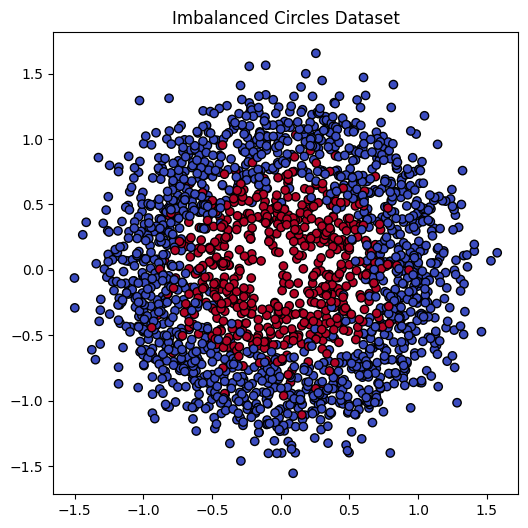

In [2]:
X, y = make_circles(n_samples=3000, factor=0.5, noise=0.2, random_state=42)

class_0 = X[y == 0]
class_1 = X[y == 1]

imbalance_ratio = 0.4
n_class_1 = int(len(class_1) * imbalance_ratio)

X_imbalanced = np.vstack([class_0, class_1[:n_class_1]])
y_imbalanced = np.hstack([np.zeros(len(class_0)), np.ones(n_class_1)]).astype(int)

indices = np.random.permutation(len(y_imbalanced))
X_imbalanced = X_imbalanced[indices]
y_imbalanced = y_imbalanced[indices]

plt.figure(figsize=(6, 6))
plt.scatter(X_imbalanced[:, 0], X_imbalanced[:, 1], c=y_imbalanced, cmap='coolwarm', edgecolors='k')
plt.title("Imbalanced Circles Dataset")
plt.show()

In [3]:
Counter(y_imbalanced)

Counter({np.int64(0): 1500, np.int64(1): 600})

In [4]:
majority_class = 0

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imbalanced, y_imbalanced, test_size=0.25, random_state=42, shuffle=True
)
X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, shuffle=True
)

In [6]:
print("train disbalance:", Counter(y_train))
print("test disbalance:", Counter(y_test))
print("val disbalance:", Counter(y_val))

train disbalance: Counter({np.int64(0): 1122, np.int64(1): 453})
test disbalance: Counter({np.int64(0): 199, np.int64(1): 63})
val disbalance: Counter({np.int64(0): 179, np.int64(1): 84})


In [7]:
model = InspireClassifier(
    n_estimators=100,
    base_estimator=DecisionTreeClassifier(
        max_depth=3,  # allows some pattern learning, but still weak
        min_samples_split=5,  # prevent very specific splits
        min_samples_leaf=3,  # reduce variance
        max_features=0.8,  # limit number of features considered at each split
        random_state=42,
    ),
)

model.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    approximate_knn_=False,
    save_history_=True,
    oversampling_per_step=100,
    cleanup_=False,
    level=logging.DEBUG,
    bp_kwargs={"neighbours": 2},
    br_kwargs={"br_treshold": 0.7}
)

DEBUG:inspire:Starting fit process.
DEBUG:inspire:Fitting KNN index.
DEBUG:inspire:Using exact KNN.
INFO:inspire:Fitting KNN index... (0.04 seconds)
DEBUG:inspire:Performing ENN cleaning.
DEBUG:inspire:Using cached training KNN results.
DEBUG:inspire:Translating indices.
DEBUG:inspire:Translating indices.
DEBUG:inspire:Removed 0 entries.
INFO:inspire:Removing outliers... (0.00 seconds)
INFO:inspire:Identified minority class: 1
INFO:inspire:Identified number of classes: 2
DEBUG:inspire:Fitting KNN index for validation set.
DEBUG:inspire:Using exact KNN.
INFO:inspire:Fitting KNN index for validation set... (0.00 seconds)
DEBUG:inspire:Identifying BR regions.
DEBUG:inspire:Using cached training KNN results.
DEBUG:inspire:Translating indices.
DEBUG:inspire:Translating indices.
INFO:inspire:Identifying border regions... (0.01 seconds)
INFO:inspire:Training models (step 0)... (0.00 seconds)
DEBUG:inspire:Evaluating batch models (2).
DEBUG:inspire:Cached preds: None
DEBUG:inspire:Identifying 

InspireClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                        max_features=0.8,
                                                        min_samples_leaf=3,
                                                        min_samples_split=5,
                                                        random_state=42),
                  n_estimators=100)

In [8]:
print(f"Removed outliers: {np.sum(model.history[0]['removed_mask'])}")
print(f"Border indexes found: {np.sum(model.history[1]['border_mask'])}")

Removed outliers: 0
Border indexes found: 181


In [9]:
i = 3

while i < len(model.history):
    y_pred = model.history[i]["preds"]
    print(f"\nIteration {int((i - 1) / 2)}:")
    print(classification_report(y_val, y_pred))

    print(f"Problematic indexes found: {np.sum(model.history[i + 1]['bp_mask'])}")
    print(
        f"Problematic overlap with border indexes: {np.sum(model.history[i + 1]['bp_mask'] & model.history[1]['border_mask'])}"
    )

    i += 2


Iteration 1:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79       179
           1       0.57      0.87      0.69        84

    accuracy                           0.75       263
   macro avg       0.74      0.78      0.74       263
weighted avg       0.81      0.75      0.76       263

Problematic indexes found: 58
Problematic overlap with border indexes: 52

Iteration 2:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79       179
           1       0.57      0.87      0.69        84

    accuracy                           0.75       263
   macro avg       0.74      0.78      0.74       263
weighted avg       0.81      0.75      0.76       263

Problematic indexes found: 58
Problematic overlap with border indexes: 52

Iteration 3:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79       179
           1       0.57      0.87      0.69    

In [10]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

INFO:inspire:Performing predictions... (0.01 seconds)


              precision    recall  f1-score   support

           0       0.96      0.70      0.81       199
           1       0.49      0.90      0.64        63

    accuracy                           0.75       262
   macro avg       0.73      0.80      0.72       262
weighted avg       0.85      0.75      0.77       262



In [11]:
X_clean = X_train[~model.history[0]["removed_mask"]]
y_clean = y_train[~model.history[0]["removed_mask"]]

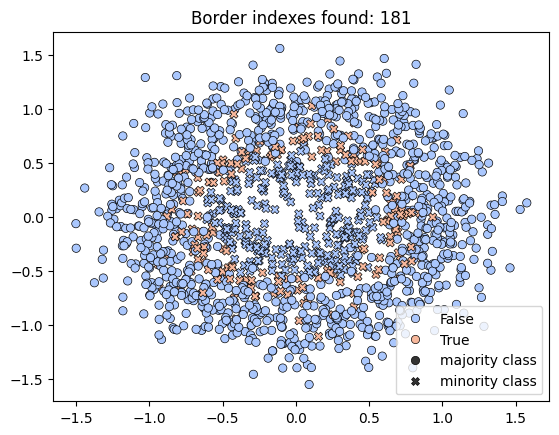

In [12]:
y_style = np.full(len(y_clean), "", dtype=object)
y_style[y_clean == majority_class] = "majority class"
y_style[y_clean != majority_class] = "minority class"

sns.scatterplot(
    x=X_clean[:, 0],
    y=X_clean[:, 1],
    hue=model.history[1]['border_mask'],
    style=y_style,
    palette="coolwarm",
    edgecolor="k",
)
plt.title(f"Border indexes found: {np.sum(model.history[1]['border_mask'])}")
plt.show()

KeyError: 'mask_proba'

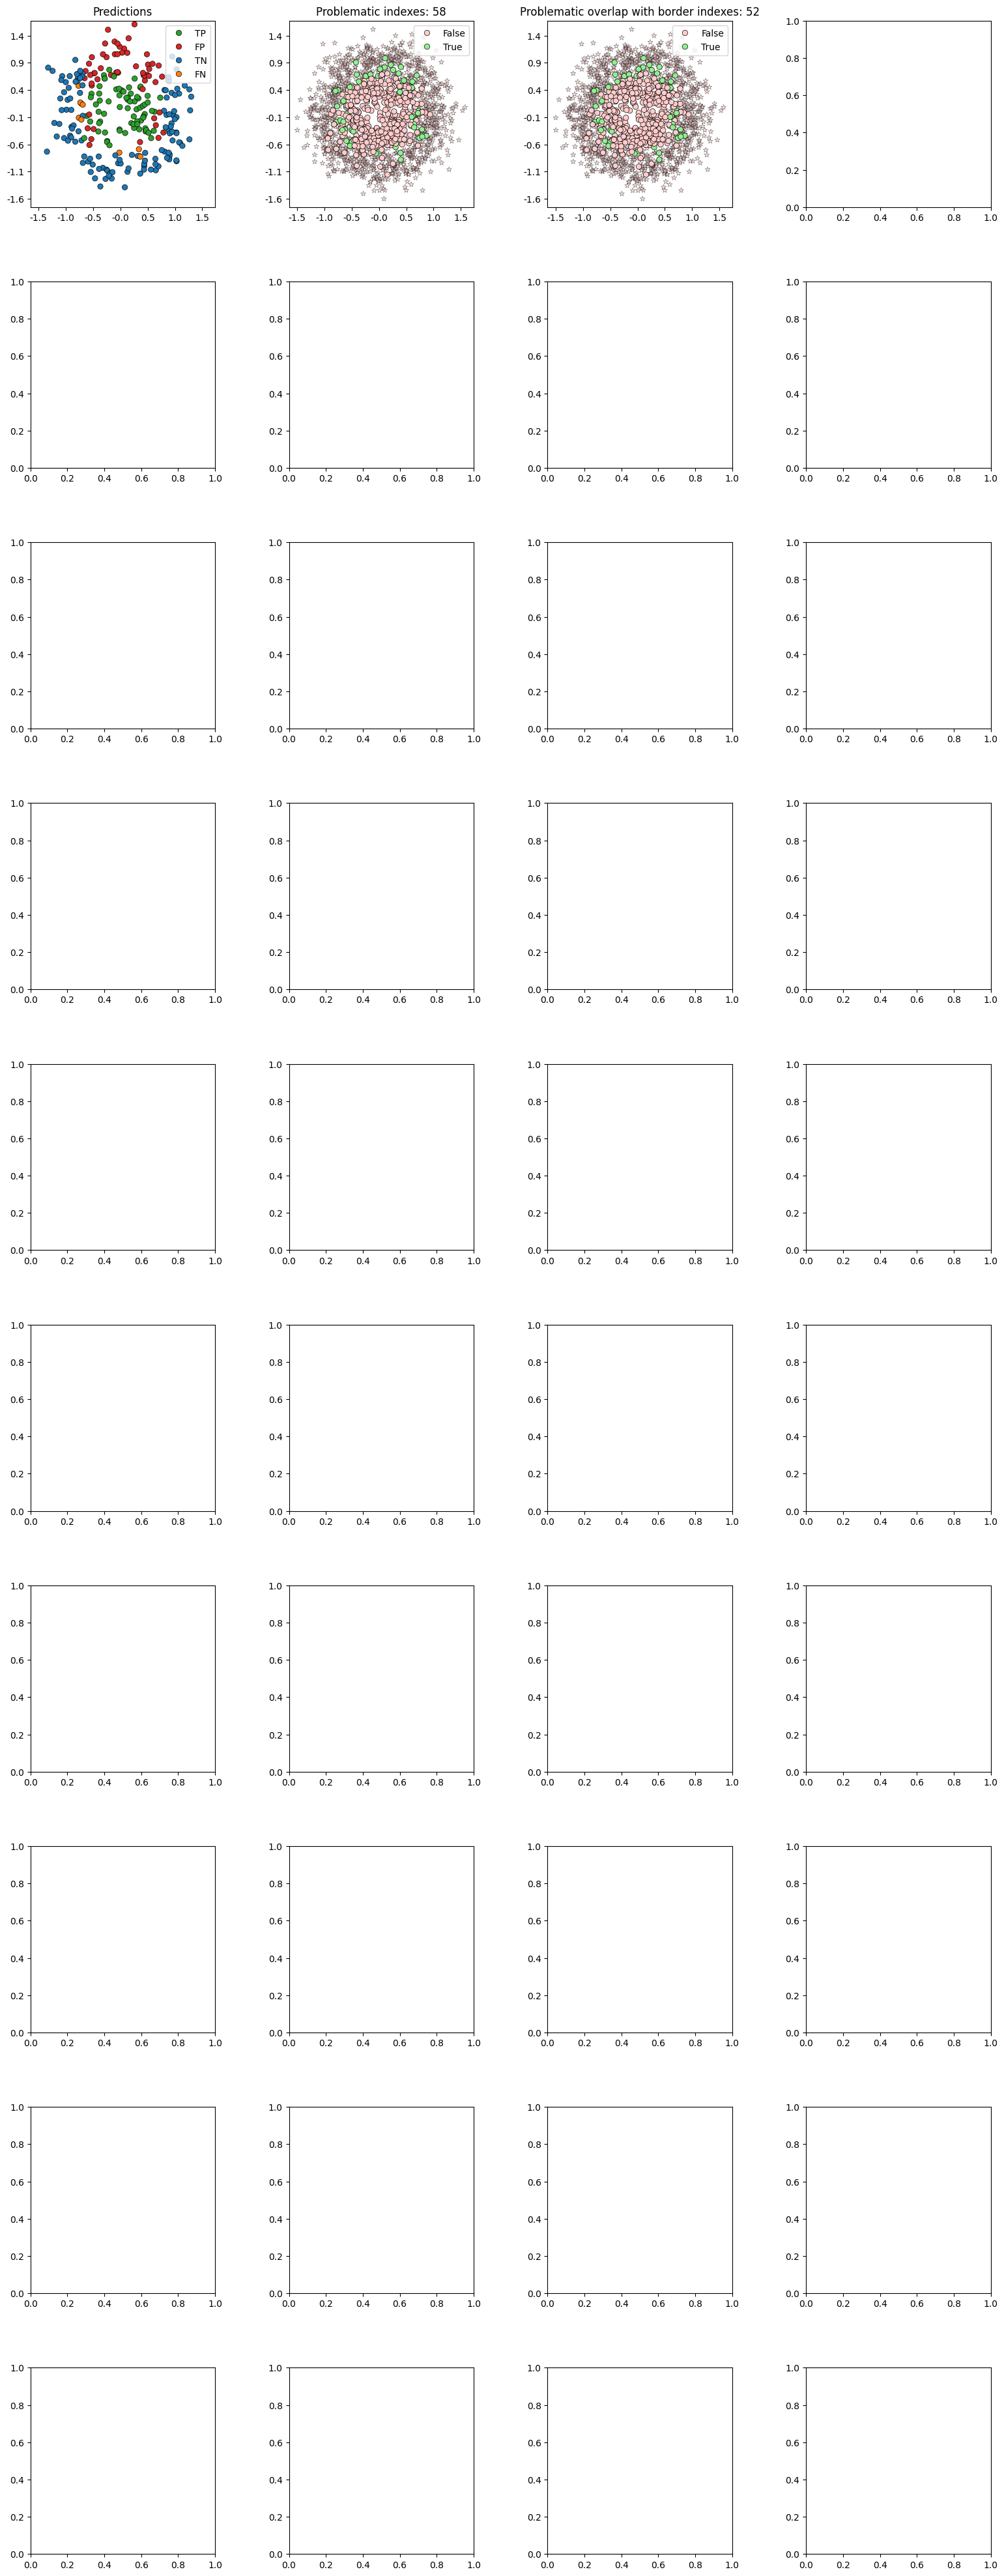

In [13]:
majority_mask = (y_clean == majority_class)

gen = list(range(3, len(model.history), 10))

rows = len(gen)
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
fig.tight_layout(pad=3.0)
fig.subplots_adjust(wspace=0.4, hspace=0.4)

for j, i in enumerate(gen):
    y_style_val = np.full(len(y_val), "", dtype=object)
    y_style_val[(model.history[i]["preds"] == y_val) & (y_val == 1)] = "TP"
    y_style_val[(model.history[i]["preds"] == y_val) & (y_val == 0)] = "TN"
    y_style_val[(model.history[i]["preds"] != y_val) & (y_val == 1)] = "FN"
    y_style_val[(model.history[i]["preds"] != y_val) & (y_val == 0)] = "FP"

    sns.scatterplot(
        x=X_val[:, 0],
        y=X_val[:, 1],
        hue=y_style_val,
        palette={
            "TP": "#2ca02c",  # green
            "TN": "#1f77b4",  # blue
            "FP": "#d62728",  # red
            "FN": "#ff7f0e",  # orange
        },
        edgecolor="k",
        ax=axs[j, 0],
        legend="full",
    )

    axs[j, 0].set_xticks(np.arange(X_clean[:, 0].min(), X_clean[:, 0].max(), 0.5))
    axs[j, 0].set_yticks(np.arange(X_clean[:, 1].min(), X_clean[:, 1].max(), 0.5))
    axs[j, 0].set_xticklabels([f"{tick:.1f}" for tick in axs[j, 0].get_xticks()])
    axs[j, 0].set_yticklabels([f"{tick:.1f}" for tick in axs[j, 0].get_yticks()])
    axs[j, 0].set_xlim(
        X_clean[:, 0].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 0].max() + X_clean[:, 0].max() / 10,
    )
    axs[j, 0].set_ylim(
        X_clean[:, 1].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 1].max() + X_clean[:, 0].max() / 10,
    )
    axs[j, 0].legend(loc="upper right")
    axs[j, 0].set_title("Predictions")
    
    palette = {
        True: "#90ee90",   # light green
        False: "#ffcccb",  # light red
    }
    sns.scatterplot(
        x=X_clean[majority_mask, 0],
        y=X_clean[majority_mask, 1],
        hue=model.history[i + 1]["bp_mask"][majority_mask],
        marker="*",
        palette=palette,
        edgecolor="k",
        ax=axs[j, 1],
        legend=False,
        alpha=0.5,
    )

    # Plot minority samples (higher alpha)
    sns.scatterplot(
        x=X_clean[~majority_mask, 0],
        y=X_clean[~majority_mask, 1],
        hue=model.history[i + 1]["bp_mask"][~majority_mask],
        palette=palette,
        edgecolor="k",
        ax=axs[j, 1],
        legend="full",  # avoid duplicate legends
        alpha=1,
    )

    axs[j, 1].legend(loc="upper right")
    axs[j, 1].set_title(f"Problematic indexes: {np.sum(model.history[i + 1]['bp_mask'])}")
    axs[j, 1].set_xticks(np.arange(X_clean[:, 0].min(), X_clean[:, 0].max(), 0.5))
    axs[j, 1].set_yticks(np.arange(X_clean[:, 1].min(), X_clean[:, 1].max(), 0.5))
    axs[j, 1].set_xticklabels([f"{tick:.1f}" for tick in axs[j, 1].get_xticks()])
    axs[j, 1].set_yticklabels([f"{tick:.1f}" for tick in axs[j, 1].get_yticks()])
    axs[j, 1].set_xlim(
        X_clean[:, 0].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 0].max() + X_clean[:, 0].max() / 10,
    )
    axs[j, 1].set_ylim(
        X_clean[:, 1].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 1].max() + X_clean[:, 0].max() / 10,
    )

    sns.scatterplot(
        x=X_clean[majority_mask, 0],
        y=X_clean[majority_mask, 1],
        hue=(model.history[i + 1]["bp_mask"] & model.history[1]["border_mask"])[majority_mask],
        marker="*",
        palette=palette,
        edgecolor="k",
        ax=axs[j, 2],
        alpha=0.5,
        legend=False
    )

    # Plot minority samples with higher alpha
    sns.scatterplot(
        x=X_clean[~majority_mask, 0],
        y=X_clean[~majority_mask, 1],
        hue=(model.history[i + 1]["bp_mask"] & model.history[1]["border_mask"])[~majority_mask],
        palette=palette,
        edgecolor="k",
        ax=axs[j, 2],
        alpha=1,
        legend="full"  # avoid legend duplication
    )
    
    axs[j, 2].legend(loc="upper right")
    axs[j, 2].set_title(
        f"Problematic overlap with border indexes: {np.sum(model.history[i + 1]['bp_mask'] & model.history[1]['border_mask'])}"
    )
    axs[j, 2].set_xticks(np.arange(X_clean[:, 0].min(), X_clean[:, 0].max(), 0.5))
    axs[j, 2].set_yticks(np.arange(X_clean[:, 1].min(), X_clean[:, 1].max(), 0.5))
    axs[j, 2].set_xticklabels([f"{tick:.1f}" for tick in axs[j, 2].get_xticks()])
    axs[j, 2].set_yticklabels([f"{tick:.1f}" for tick in axs[j, 2].get_yticks()])
    axs[j, 2].set_xlim(
        X_clean[:, 0].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 0].max() + X_clean[:, 0].max() / 10,
    )
    axs[j, 2].set_ylim(
        X_clean[:, 1].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 1].max() + X_clean[:, 0].max() / 10,
    )
    
    mask_proba = model.history[i + 1]["mask_proba"]
    mask_miss = model.history[i + 1]["mask_miss"]
    val_bp_mask = model.history[i + 1]["val_bp_mask"]
    mask = mask_proba | mask_miss
    
    hue = np.zeros(len(X_val), dtype=int)
    hue[mask_proba] += 1
    hue[mask_miss] -= 1
    
    
    sns.scatterplot(
        x=X_val[:, 0],
        y=X_val[:, 1],
        ax=axs[j, 3],
        alpha=0.1,
        color="blue",
        legend=False,
    )
    sns.scatterplot(
        x=X_val[mask, 0],
        y=X_val[mask, 1],
        hue=hue[mask],
        ax=axs[j, 3],
        alpha=1,
        palette={
            -1: "#d62728",  # red
            0: "#ff7f0e",  # orange
            1: "#2ca02c",  # green
        },
    )
    axs[j, 3].legend(
        handles=[
            plt.Line2D([0], [0], marker='o', color='w', label='miss', markerfacecolor="#d62728", markersize=10),
            plt.Line2D([0], [0], marker='o', color='w', label='both', markerfacecolor="#ff7f0e", markersize=10),
            plt.Line2D([0], [0], marker='o', color='w', label='proba', markerfacecolor="#2ca02c", markersize=10),
        ],
        loc="upper right"
    )
    axs[j, 3].set_title("Bp analysis")

    if i > 3:
        print(
            f"Number of changed preds: {np.sum(model.history[i]['preds'] != model.history[i-2]['preds'])}"
        )
        
plt.show()

In [14]:
model.history[i + 1]

{'name': 'Batch__1__oversampling',
 'oversampling_indeces': array([  65,  188,  208,  222,  233,  234,  289,  300,  333,  339,  369,
         380,  397,  398,  429,  481,  508,  529,  536,  567,  637,  673,
         707,  752,  766,  768,  783,  789,  793,  821,  858,  875,  890,
         912,  936,  942,  956, 1022, 1057, 1088, 1193, 1230, 1290, 1307,
        1338, 1358, 1365, 1404, 1468, 1481, 1502, 1565]),
 'X_synth': array([[-0.55646268, -0.06425937],
        [-0.05044085, -0.32423724],
        [ 0.280537  ,  0.26272297],
        [-0.3079322 , -0.59593083],
        [ 0.36376968, -0.18815214],
        [-0.25788038, -0.41439533],
        [-0.30663674, -0.55990861],
        [-0.09287855,  0.38815258],
        [-0.21720237,  0.25807072],
        [ 0.11130786,  1.03022027],
        [ 0.60534853,  0.48537305],
        [-0.39460736,  0.72254674],
        [ 0.77658533, -0.40985332],
        [ 0.26532934,  0.52576207],
        [ 0.13662166,  0.3169315 ],
        [-0.33274038, -0.47824684],
